In [ ]:
#Install the required packages

In [45]:
!mamba install pandas
!mamba install seaborn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 6.10310000000149 seconds
All requested packages already installed.
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 5.078 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ patsy                         1.0.2                         py313h1804a44_1               emscripten-forge              
+ seaborn                       0.13.2                        hd8ed1ab_3                    conda-forge                   
+ seaborn-base                  0.13.2          

In [ ]:
#import packages for analysis

In [64]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#get working directory

In [5]:
cwd=os.getcwd()
print(cwd)

/drive/Medical-data-visualizer


In [53]:
df=pd.read_csv('/drive/Medical-data-visualizer/medical_examination.csv')

In [ ]:
#get the shape of the data

In [37]:
df.shape

(70000, 13)

In [ ]:
#print the head of our dataframe

In [54]:
df.head()

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
#create an overweight coloumn and set it to binary values with bmi value as the condition

In [55]:
df.loc[:,"overweight"] = (df["weight"] / (df["height"]/100)**2 > 25).astype(int)
df.head()

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,0


In [ ]:
#modify the colesterol level coloumn to set it to zero if not above 1 and one of it is.

In [56]:
df.loc[:,["cholesterol", "gluc"]] = (df[["cholesterol", "gluc"]] > 1).astype(int)
df.head()

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,0,0,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,1,0,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,1,0,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,0,0,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,0,0,0,0,0,0,0


In [ ]:
#a categorical plot of our data

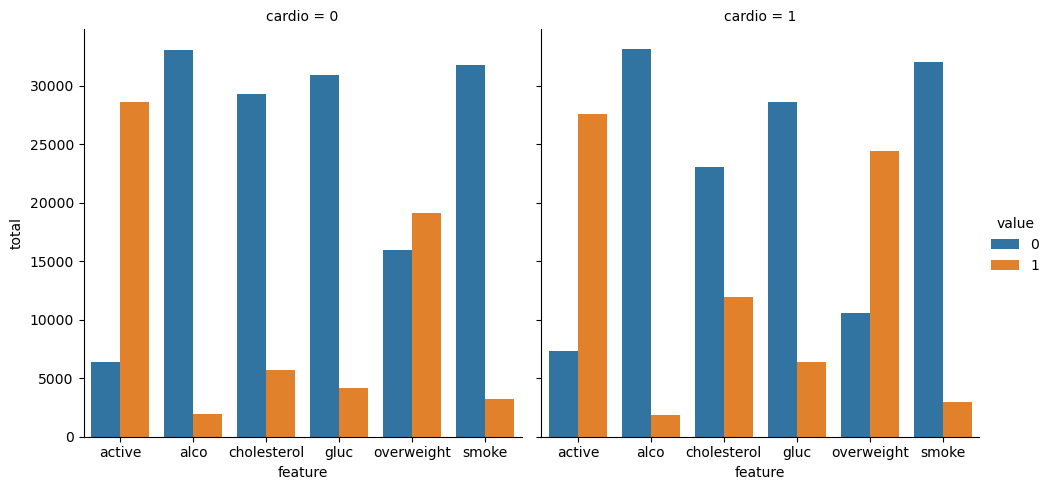

In [62]:
# Choose categorical variables
variables = ["cholesterol", "gluc", "overweight", "active", "smoke", "alco"]

# Convert to long format (melt)
df_cat = pd.melt(df, id_vars=["cardio"], value_vars=variables)

# Group and count
df_cat = df_cat.groupby(["cardio", "variable", "value"]).size().reset_index(name="total")

# IMPORTANT: rename 'variable' column to 'feature' for catplot to work correctly
df_cat = df_cat.rename(columns={"variable": "feature"})

# Draw categorical plot
sns.catplot(
    x="feature", 
    y="total", 
    hue="value", 
    col="cardio", 
    data=df_cat, 
    kind="bar"
)

In [ ]:
#plot heatmap

<Axes: >

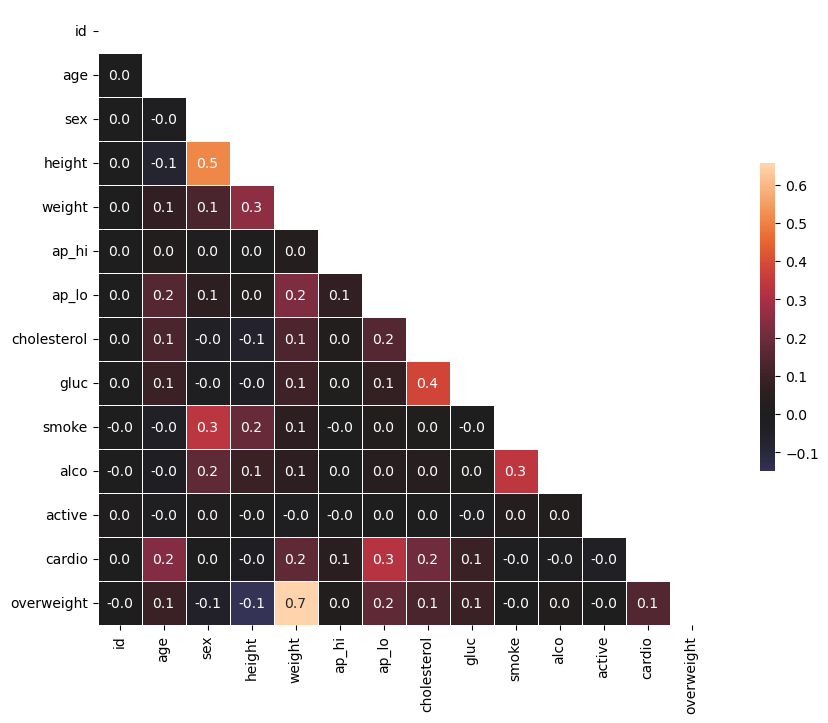

In [67]:

# Clean the data
df_heat = df[
        (df['ap_lo'] <= df['ap_hi']) & 
        (df['height'] >= df['height'].quantile(0.025)) &
        (df['height'] <= df['height'].quantile(0.975)) &
        (df['weight'] >= df['weight'].quantile(0.025)) &
        (df['weight'] <= df['weight'].quantile(0.975))
    ]
# Calculate correlation matrix
corr = df_heat.corr()
# Generate mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
# Set up matplotlib figure
fig, ax = plt.subplots(figsize=(12, 8))
# Draw heatmap
sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".1f",
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.5}
)